# Project Title : CNN-Based Image Classification using OpenCV Preprocessing

# Description:

In this project a convolutional Neural Network (CNN) was developed to classify images into different classes: airplane, car, fruit, cat, motorbike, Dog. These classes were selected because they are visually distinct and suitable for image classification.

# OpenCV
OpenCV was used for image preprocessing tasks such as reading images, converting color format, resizing images
to a fixed size, and normalizing pixel values. This helped prepare the dataset before feeding it into the CNN model.

# CNN Architecture:
The CNN model consisted of convolution layers, max-pooling layers, batch normalization, flatten layer, dense layer,
dropout layer, and output layer with softmax activation.

# Preprocessing Steps:
1. Read images using OpenCV
2. Convert BGR to RGB
3. Resize all images to 128x128
4. Normalize pixel values to range [0,1]
5. Apply data augmentation on training images

# Performance:
The model was evaluated using accuracy, confusion matrix, precision, and recall.

# Challenges Faced:
Some challenges included handling different image sizes, maintaining class balance, and improving model generalization.


# Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define Dataset path and Classes

In [3]:
dataset_path = '/content/drive/MyDrive/Image'

# Change these names exactly according to your folder names
classes = ["Aeroplane", "Dogs", "Cat","Car","Fruits","Motorbike","Person"]

img_size = 128

# Load and preprocess images using OpenCV

In [4]:
data = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    label = classes.index(class_name)

    if not os.path.exists(class_path):
        print(f"Folder not found: {class_path}")
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Read image using OpenCV
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize image
            img = cv2.resize(img, (img_size, img_size))

            # Normalize pixel values
            img = img / 255.0

            data.append(img)
            labels.append(label)

        except Exception as e:
            print(f"Error loading {img_path}: {e}")

# Convert to Numpy Arrays

In [5]:
X = np.array(data, dtype='float32')
y = np.array(labels)

print('Total images loaded :',len (X))
print('Shape of X :',X.shape)
print('Shape of y :', y.shape)

Total images loaded : 621
Shape of X : (621, 128, 128, 3)
Shape of y : (621,)


# Display some sample Images

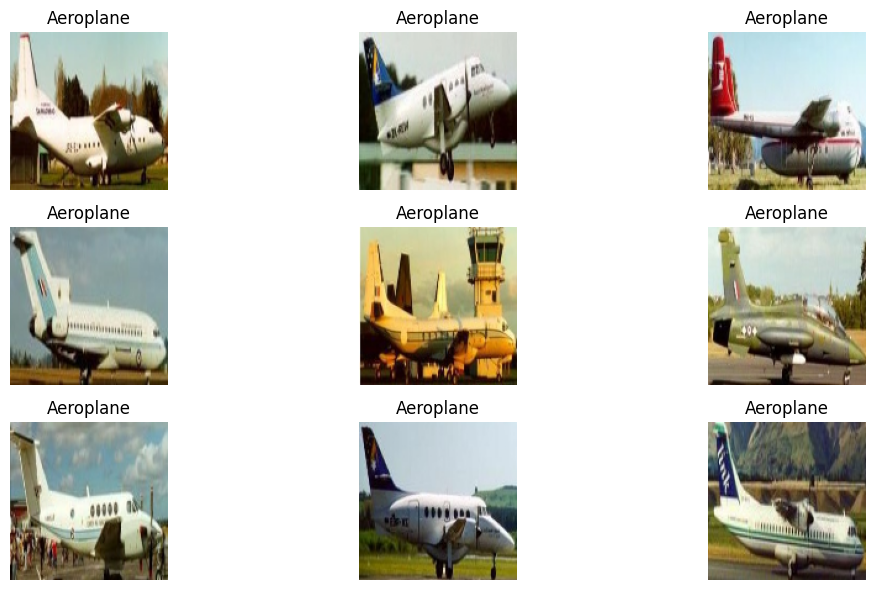

In [6]:
plt.figure(figsize=(12,6))

for i in range(min(9, len(X))):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(classes[y[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Train, Validation and test split

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (496, 128, 128, 3)
Validation set: (62, 128, 128, 3)
Test set: (63, 128, 128, 3)


# Convert labels to categorical

In [8]:
from tensorflow.keras.utils import to_categorical

num_classes = len(classes)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Data Augmentation

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 20,
    zoom_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True
)

datagen.fit(X_train)

# Build CNN model

In [10]:
model = Sequential([
    # Layer 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Layer 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Layer 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5), # Ratta maarne se rokne ke liye
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,927 (12.61 MB)

 Trainable params: 3,305,735 (12.61 MB)

 Non-trainable params: 192 (768.00 B)

# Compile the model

In [11]:
model.compile(
 optimizer = 'adam',
 loss = 'categorical_crossentropy',
 metrics = ['accuracy']
)

# Train the model

In [12]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val,y_val_cat),
    epochs = 30
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2863 - loss: 5.3231 - val_accuracy: 0.0968 - val_loss: 1.9444
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4315 - loss: 1.6042 - val_accuracy: 0.2258 - val_loss: 1.9151
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4758 - loss: 1.4221 - val_accuracy: 0.3387 - val_loss: 1.8277
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5605 - loss: 1.2098 - val_accuracy: 0.2903 - val_loss: 1.8538
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6048 - loss: 1.1954 - val_accuracy: 0.2419 - val_loss: 1.7897
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5806 - loss: 1.2815 - val_accuracy: 0.2903 - val_loss: 1.8057
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5927 - loss: 1.1347 - val_accuracy: 0.2581 - val_loss: 1.8620
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6028 - loss: 1.0770 - val_accuracy: 0.2742 - val_loss:

# Evaluate model on test data

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print('Test Loss: ', test_loss)
print('Test Accuracy: ', test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.7778 - loss: 0.6542
Test Loss:  0.654211163520813
Test Accuracy:  0.7777777910232544


# Predictions

In [14]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step


# Accuracy, precision, recall

In [15]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test,y_pred,average='weighted')
rec = recall_score(y_test,y_pred,average='weighted')

print(f"Accuracy: {acc}")
print(f'Precision: {prec}')
print(f'Recall: {rec}')

Accuracy: 0.7777777777777778
Precision: 0.770046504914365
Recall: 0.7777777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix

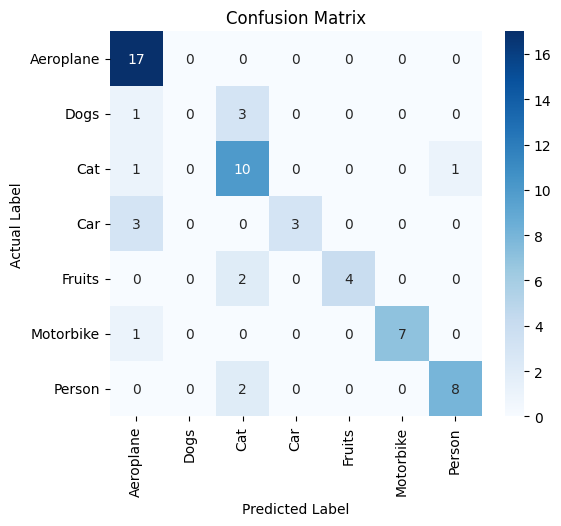

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

# Classification report

In [17]:
print(classification_report(y_test, y_pred, target_names=classes))

              precision    recall  f1-score   support

   Aeroplane       0.74      1.00      0.85        17
        Dogs       0.00      0.00      0.00         4
         Cat       0.59      0.83      0.69        12
         Car       1.00      0.50      0.67         6
      Fruits       1.00      0.67      0.80         6
   Motorbike       1.00      0.88      0.93         8
      Person       0.89      0.80      0.84        10

    accuracy                           0.78        63
   macro avg       0.75      0.67      0.68        63
weighted avg       0.77      0.78      0.75        63



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Display test images with actual and predicted labels

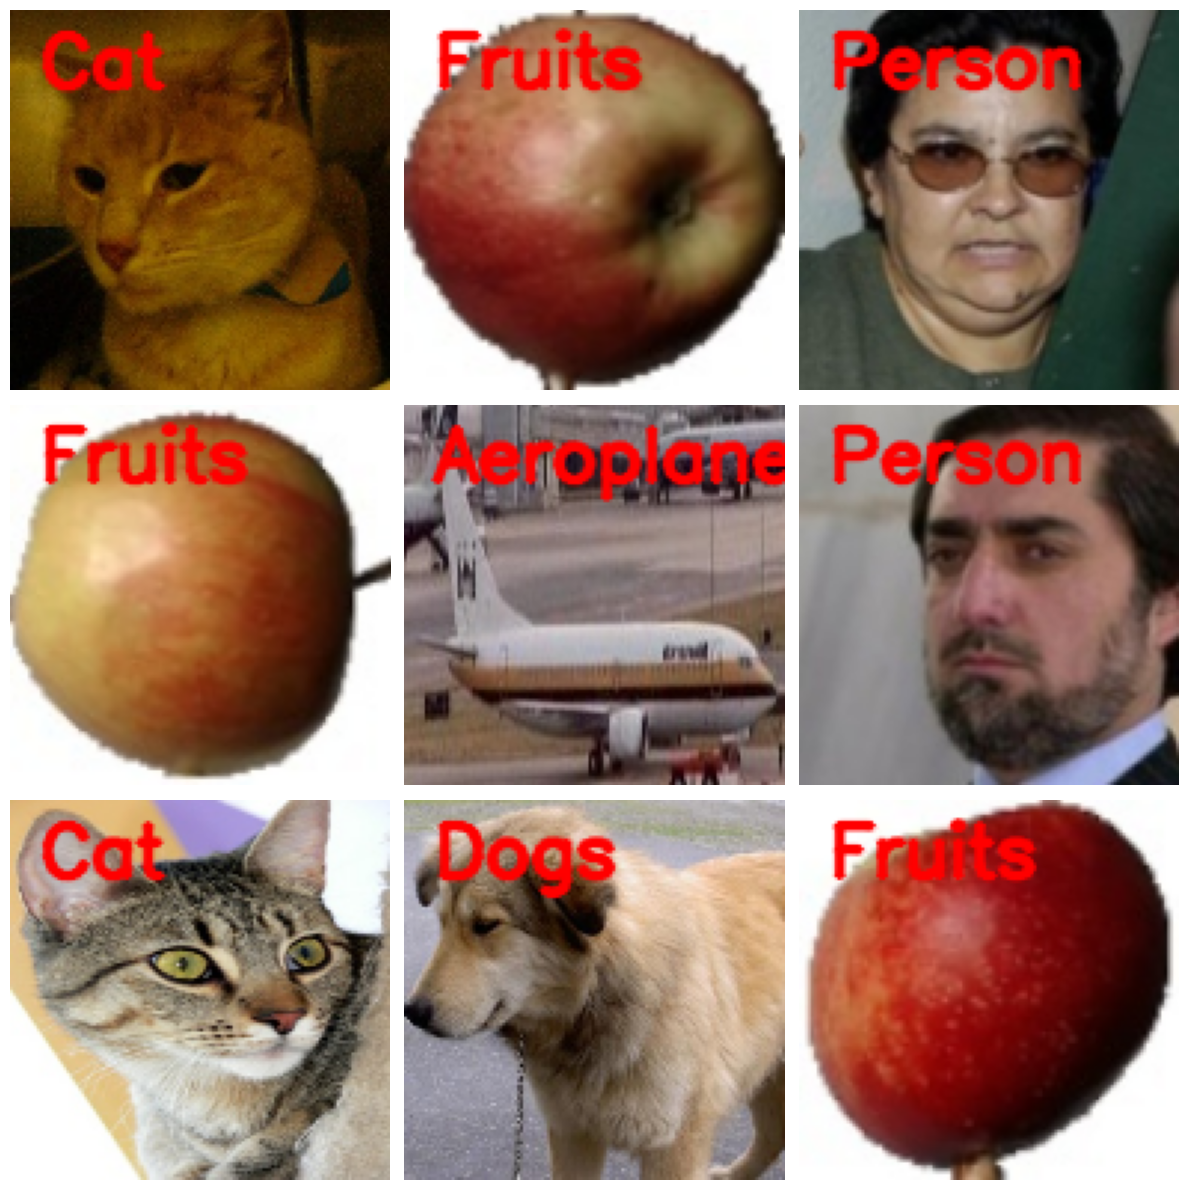

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

plt.figure(figsize=(12, 12))

random_idx = np.random.choice(len(X), min(9, len(X)), replace=False)

for j, idx in enumerate(random_idx):
    img = (X[idx] * 255).astype("uint8").copy()

    img = cv2.putText(
        img,
        classes[y[idx]],
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
        cv2.LINE_AA
    )

    plt.subplot(3, 3, j + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()